In [3]:
#1
from sklearn.datasets import load_wine

wine = load_wine()


In [4]:
#2
import pandas as pd

df = pd.DataFrame(wine.data, columns=wine.feature_names)

df['target'] = wine.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [5]:
#3
print("Caracteristici:", wine.feature_names)

Caracteristici: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


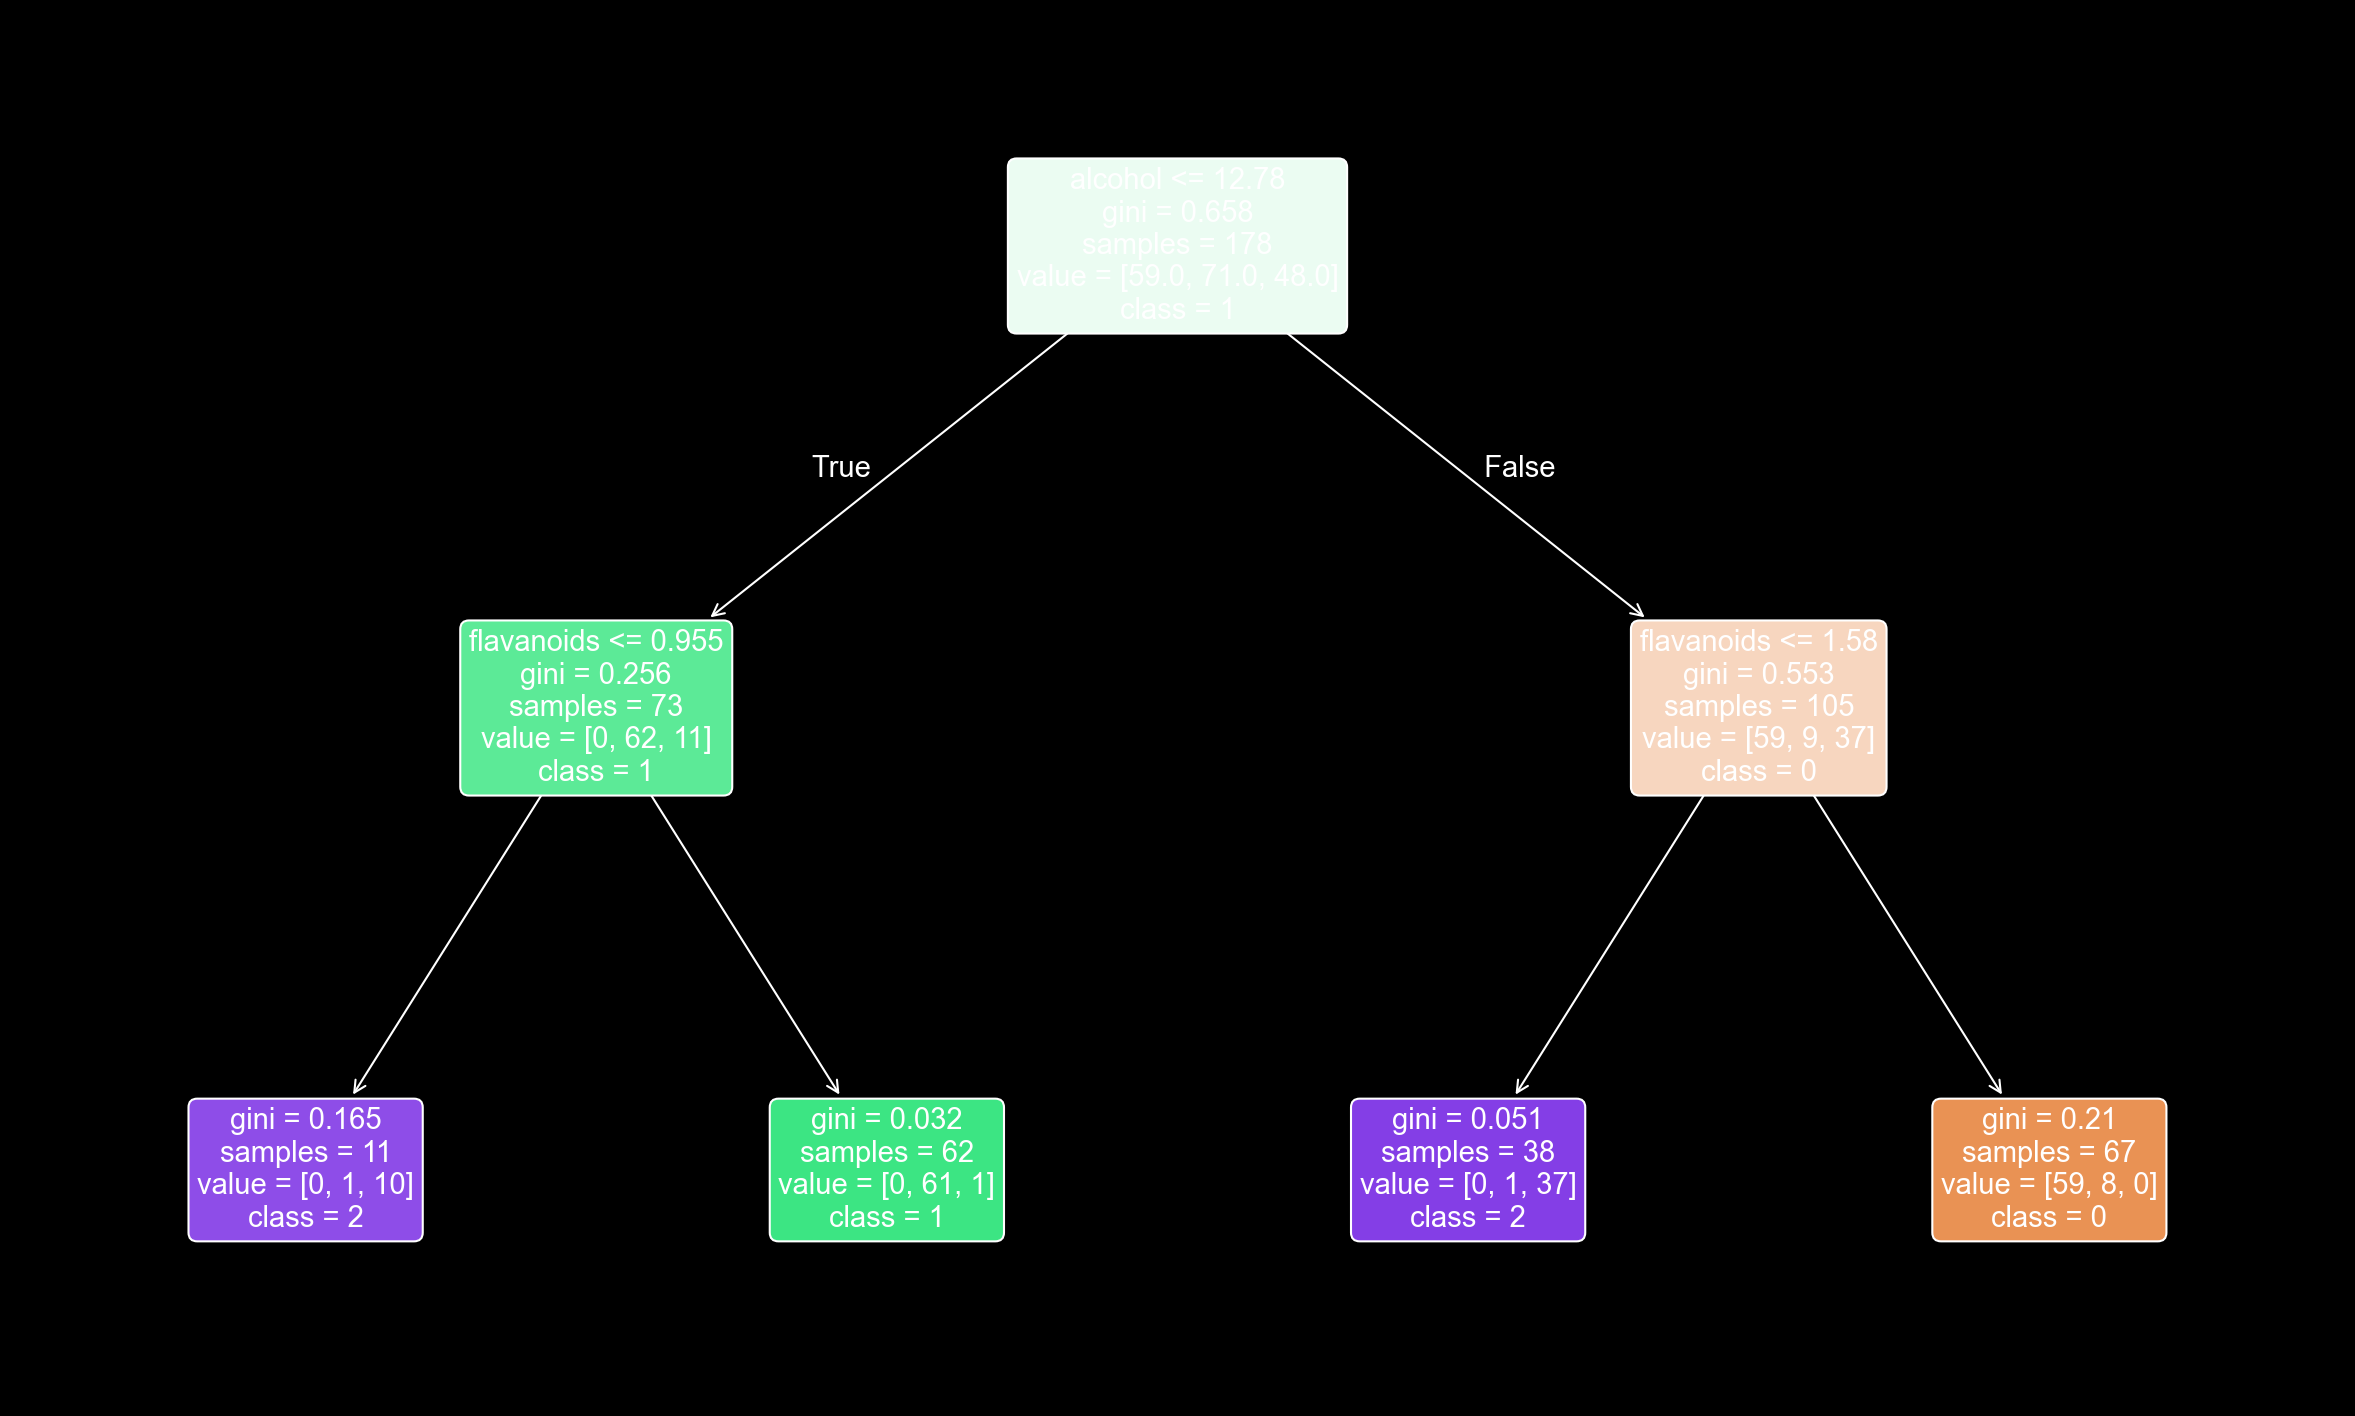

Primul nod verifica valoarea pentru alcohol.
Al doilea nivel continua separarea folosind flavanoids.
Frunzele arborelui reprezinta clasele prezise.


In [15]:
#4
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

X = df[['alcohol', 'flavanoids']]

y = df['target']

model = DecisionTreeClassifier(max_depth=2)

model.fit(X, y)

plt.figure(figsize=(20,12), dpi=150)

plot_tree(
    model,
    feature_names=['alcohol', 'flavanoids'],
    class_names=['0', '1', '2'],
    filled=True,
    rounded=True,
    fontsize=14
)

plt.show()

print("Primul nod verifica valoarea pentru alcohol.")
print("Al doilea nivel continua separarea folosind flavanoids.")
print("Frunzele arborelui reprezinta clasele prezise.")

In [16]:
#5
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

X = df.drop('target', axis=1)

y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = DecisionTreeClassifier(max_depth=None)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Acuratete:", accuracy)

Acuratete: 0.9444444444444444


In [21]:
#6
from sklearn.tree import DecisionTreeClassifier

X = df.drop('target', axis=1)

y = df['target']

tree = DecisionTreeClassifier(random_state=1)

tree.fit(X, y)

importance_values = tree.feature_importances_

for name, value in zip(X.columns, importance_values):
    print(name, "->", value)

print("Caracteristicile cu cele mai mari scoruri au cea mai mare influenta asupra clasificarii realizate de arbore.")
print("Valorile apropiate de 0 indica faptul ca acele caracteristici au fost utilizate foarte putin sau deloc.")

alcohol -> 0.012570564071187309
malic_acid -> 0.014223159778821876
ash -> 0.0
alcalinity_of_ash -> 0.0
magnesium -> 0.0534597951279922
total_phenols -> 0.0
flavanoids -> 0.16704836491408806
nonflavanoid_phenols -> 0.0
proanthocyanins -> 0.0
color_intensity -> 0.0
hue -> 0.058185091460406506
od280/od315_of_diluted_wines -> 0.3120425747831769
proline -> 0.38247044986432716
Caracteristicile cu cele mai mari scoruri au cea mai mare influenta asupra clasificarii realizate de arbore.
Valorile apropiate de 0 indica faptul ca acele caracteristici au fost utilizate foarte putin sau deloc.
